# Batch 10 — Full Impact Assessment

Same 4 scenarios (2 mining stages × 2 planning strategies, Kribi port).

**Updates vs batch07**
- Deforestation now in **km²** (was ha); buffer labels in km (`0 → 1.0 km`)
- Fragmentation now reports **before / after / delta** for both 50 km and 100 km windows, plus the count of affected landscape windows

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

RESULTS_DIR = Path("../model/results/impact-assessment/batch10")

# Window sizes (km) as they appear in column names
WINDOW_SIZES = [50, 100]

# ── Load and parse all 4 scenario CSVs ───────────────────────────────────────
def parse_scenario(s):
    stage     = "Late + Early Stage" if s.startswith("late_and_early") else "Late Stage Only"
    mask_type = "Protected Areas"    if "protected_areas" in s           else "No Mask"
    return stage, mask_type

df = pd.concat(
    [pd.read_csv(f) for f in sorted(RESULTS_DIR.glob("assessment_*.csv"))],
    ignore_index=True
)
df[["mining_stage", "mask_type"]] = pd.DataFrame(
    df["scenario"].apply(parse_scenario).tolist(), index=df.index
)

# Compute before/after deltas for fragmentation
for w in WINDOW_SIZES:
    df[f"delta_patches_{w}km"] = df[f"fragmentation_patches_after_{w}km"] - df[f"fragmentation_patches_before_{w}km"]
    df[f"delta_index_{w}km"]   = df[f"fragmentation_index_after_{w}km"]   - df[f"fragmentation_index_before_{w}km"]

print(f"Loaded {len(df)} scenarios  ×  {len(df.columns)} columns")
df[["scenario", "mining_stage", "mask_type", "total_km", "total_cost_usd",
    "defor_action_km2", "delta_patches_100km", "delta_index_100km"]]

In [ ]:
# Summary table
road_cols  = ["paved_km", "unpaved_km", "to_be_built_km", "total_km"]
cost_cols  = ["upgrade_cost_usd", "new_build_cost_usd", "total_cost_usd"]
defor_cols = ["defor_upgrade_km2", "defor_build_km2", "defor_action_km2"]
frag_cols  = [f"delta_patches_{w}km" for w in WINDOW_SIZES] + [f"delta_index_{w}km" for w in WINDOW_SIZES]

fmt = (
    {c: "{:.1f}"   for c in road_cols}
  | {c: "${:,.0f}" for c in cost_cols}
  | {c: "{:.2f}"   for c in defor_cols}
  | {c: "{:.0f}"   for c in [f"delta_patches_{w}km" for w in WINDOW_SIZES]}
  | {c: "{:.2e}"   for c in [f"delta_index_{w}km"   for w in WINDOW_SIZES]}
)

display_cols = ["mining_stage", "mask_type"] + road_cols + cost_cols + defor_cols + frag_cols

df[display_cols].style \
    .set_caption("Batch 10 — impact assessment summary") \
    .format({k: v for k, v in fmt.items() if k in display_cols}) \
    .set_table_styles([{"selector": "th", "props": [("font-size", "10px"), ("white-space", "nowrap")]}]) \
    .highlight_max(subset=defor_cols, color="#ffd9cc") \
    .highlight_min(subset=["total_cost_usd"], color="#d4edda")

## Road classification & investment

In [39]:
# Shared layout constants (reused in every 2-subplot chart below)
STRATEGY_ORDER  = ["No Mask", "Protected Areas"]
STRATEGY_LABELS = ["Cost effective", "Avoid protected areas"]
mining_scenarios = [
    {"stage": "Late Stage Only",    "title": "Most Likely Scenario",   "subtitle": "Late-stage mines only"},
    {"stage": "Late + Early Stage", "title": "More Ambitious Scenario", "subtitle": "All planned mines"},
]
x_pos = np.arange(len(STRATEGY_ORDER))
bar_w = 0.55

def two_panel_bar(df_src, cats, colors, labels, ylabel, title, scale=1, fmt="{:.0f}",
                  min_label=None, save_name=None):
    """
    Generic 2-subplot stacked bar: one panel per mining stage,
    x-axis = planning strategy, stacks = categories.
    """
    fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharey=True)
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.02)

    for ax, scenario in zip(axes, mining_scenarios):
        stage = scenario["stage"]
        rows  = {mt: df_src.loc[(df_src["mining_stage"] == stage) &
                                 (df_src["mask_type"] == mt)].iloc[0]
                 for mt in STRATEGY_ORDER}
        bottoms = np.zeros(len(STRATEGY_ORDER))
        for cat, color, label in zip(cats, colors, labels):
            vals = np.array([rows[mt][cat] / scale for mt in STRATEGY_ORDER])
            bars = ax.bar(x_pos, vals, bar_w, bottom=bottoms,
                          color=color, edgecolor="black", linewidth=0.8, label=label)
            threshold = min_label if min_label is not None else (vals.max() * 0.05)
            for bar, v, bot in zip(bars, vals, bottoms):
                if v > threshold:
                    ax.text(bar.get_x() + bar.get_width()/2, bot + v/2,
                            fmt.format(v), ha="center", va="center",
                            fontsize=9, fontweight="bold", color="white")
            bottoms += vals
        ax.set_xticks(x_pos); ax.set_xticklabels(STRATEGY_LABELS, fontsize=10)
        ax.set_title(f"{scenario['title']}\n({scenario['subtitle']})",
                     fontsize=11, fontweight="bold")
        ax.set_ylabel(ylabel)
        ax.yaxis.grid(True, linestyle="--", alpha=0.4); ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    fig.legend(handles=[mpatches.Patch(color=c, label=l) for c, l in zip(colors, labels)],
               loc="lower center", ncol=len(cats), fontsize=10,
               bbox_to_anchor=(0.5, -0.08), frameon=True)
    plt.tight_layout()
    if save_name:
        plt.savefig(RESULTS_DIR / save_name, dpi=150, bbox_inches="tight")
    plt.show()

print("Helper ready.")

Helper ready.


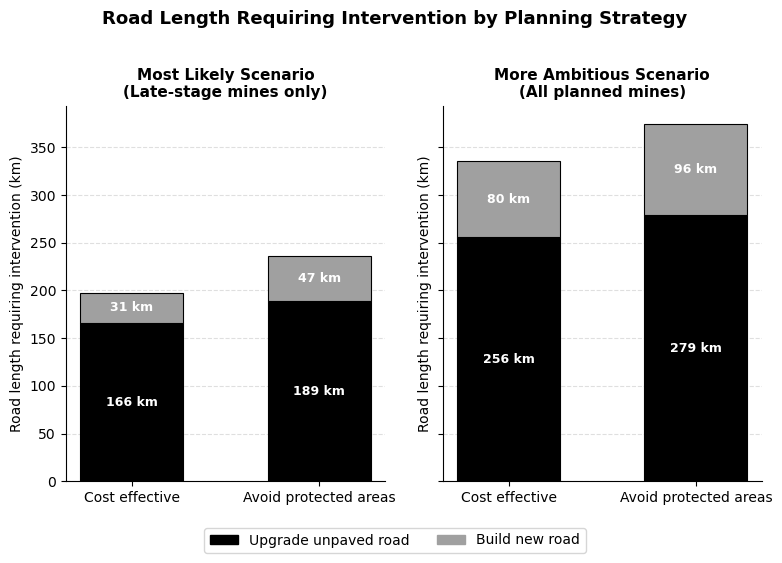

In [40]:
two_panel_bar(
    df, cats=["unpaved_km", "to_be_built_km"],
    colors=["#000000", "#a0a0a0"],
    labels=["Upgrade unpaved road", "Build new road"],
    ylabel="Road length requiring intervention (km)",
    title="Road Length Requiring Intervention by Planning Strategy",
    fmt="{:.0f} km", min_label=4,
    save_name="fig_investment_km.png"
)

Upgrading existing unpaved roads is the primary intervention in all scenarios, accounting for **~84% of required road km** in the Most Likely case and ~76% in the More Ambitious case. The Most Likely scenario requires intervention on ~197 km (cost-effective route) to ~236 km (avoiding protected areas), while the More Ambitious scenario demands ~335–375 km due to the larger number of mines. Routing around protected areas consistently adds 15–20% more road km in both mining scopes, as the alternative alignments must take longer detours through unprotected terrain.

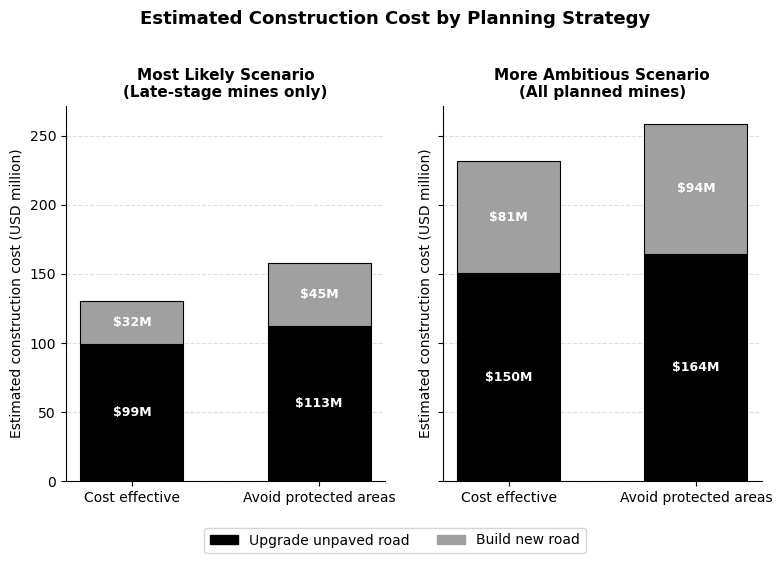

In [41]:
two_panel_bar(
    df, cats=["upgrade_cost_usd", "new_build_cost_usd"],
    colors=["#000000", "#a0a0a0"],
    labels=["Upgrade unpaved road", "Build new road"],
    ylabel="Estimated construction cost (USD million)",
    title="Estimated Construction Cost by Planning Strategy",
    scale=1e6, fmt="${:.0f}M", min_label=2,
    save_name="fig_investment_usd.png"
)

Total estimated construction cost ranges from **$131M** (Most Likely — cost effective) to **$259M** (More Ambitious — avoid protected areas). The More Ambitious scenario is roughly **77% more expensive** than the Most Likely equivalent, driven by both longer upgrade km and substantially more new-build km. New road construction carries a disproportionately high cost per km relative to upgrading: in the Most Likely cost-effective scenario, new builds represent only 16% of road km but account for 24% of total cost. Routing around protected areas adds $27–28M (approximately 12–21% cost premium) across both mining scopes, a meaningful but potentially acceptable cost for the biodiversity benefit if the protection is effective.

## Deforestation risk

Canopy-cover-weighted forest area (km²) within a direct corridor along each road action (upgrade or new build).

In [ ]:
# Deforestation risk — upgrade vs new-build, 2-subplot style
two_panel_bar(
    df, cats=["defor_upgrade_km2", "defor_build_km2"],
    colors=["#000000", "#a0a0a0"],
    labels=["Upgrade unpaved road", "Build new road"],
    ylabel="Canopy-weighted deforestation risk (km²)",
    title="Deforestation Risk by Planning Strategy",
    fmt="{:.1f}", min_label=1,
    save_name="fig_deforestation.png"
)

Mining scope is the dominant driver of deforestation risk. The More Ambitious scenarios generate roughly **60% more canopy-weighted forest loss** than their Most Likely counterparts. Upgrading existing unpaved roads (black) contributes the larger share of risk across all scenarios, despite involving existing corridors rather than greenfield construction — these roads already pass through substantial forest cover.

Planning strategy has a small but consistent effect: routing around protected areas adds additional deforestation risk, as longer alternative alignments must traverse other forested corridors outside the protected zone.

New road construction (gray) carries a disproportionately high deforestation risk per km relative to upgrading. In the Most Likely cost-effective scenario, new builds represent only ~16% of road km but account for ~24% of total deforestation risk. Routing around protected areas adds a small consistent deforestation penalty (~5–8 km²) mainly through additional new-build exposure, as the longer detour alignments must enter forested corridors outside the protected zone.

## Forest fragmentation

The landscape is divided into square windows (50 km and 100 km). Within each window, the number of intact-forest patches and a patch-size fragmentation index are computed before and after road construction.

**Metrics reported:**
- **Δ patches** — new intact-forest patches created (roads split existing continuous forest)
- **Δ index** — change in fragmentation index (higher = more fragmented; values are small because roads affect a tiny fraction of each window)
- **Affected windows** — number of landscape windows that contain at least one new action road

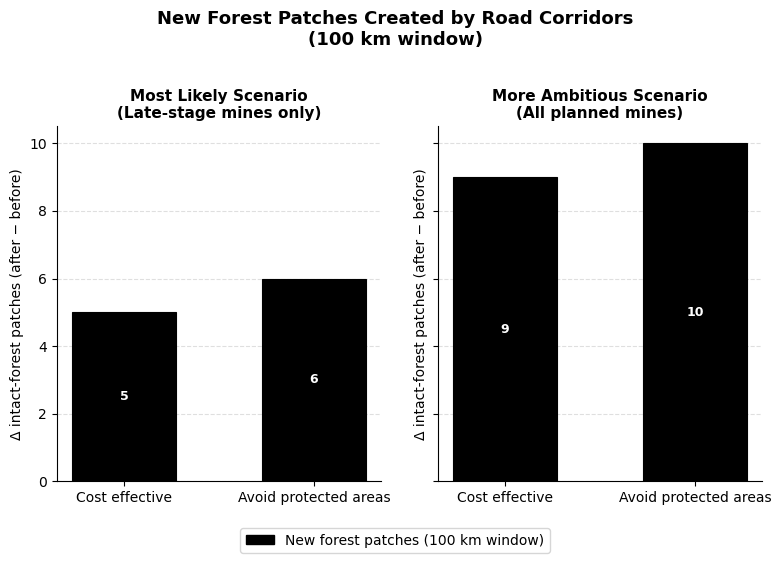

In [45]:
# New patches created (delta) — 100 km window, 2-subplot style
two_panel_bar(
    df, cats=["delta_patches_100km"],
    colors=["#000000"],
    labels=["New forest patches (100 km window)"],
    ylabel="Δ intact-forest patches (after − before)",
    title="New Forest Patches Created by Road Corridors\n(100 km window)",
    fmt="{:.0f}", min_label=0,
    save_name="fig_fragmentation_delta_patches.png"
)

New road corridors create between **5 and 10 additional intact-forest patches** within 100 km landscape windows, depending on scenario. The More Ambitious scenarios (9–10 patches) produce roughly double the patch creation of the Most Likely scenarios (5–6 patches), directly reflecting the greater length of road built. Routing around protected areas adds one extra patch in both mining scopes, as the longer detour alignment crosses an additional forest boundary. All values are small relative to the baseline of ~101,714 patches, indicating that the proposed corridors fragment forest at a local rather than landscape scale.

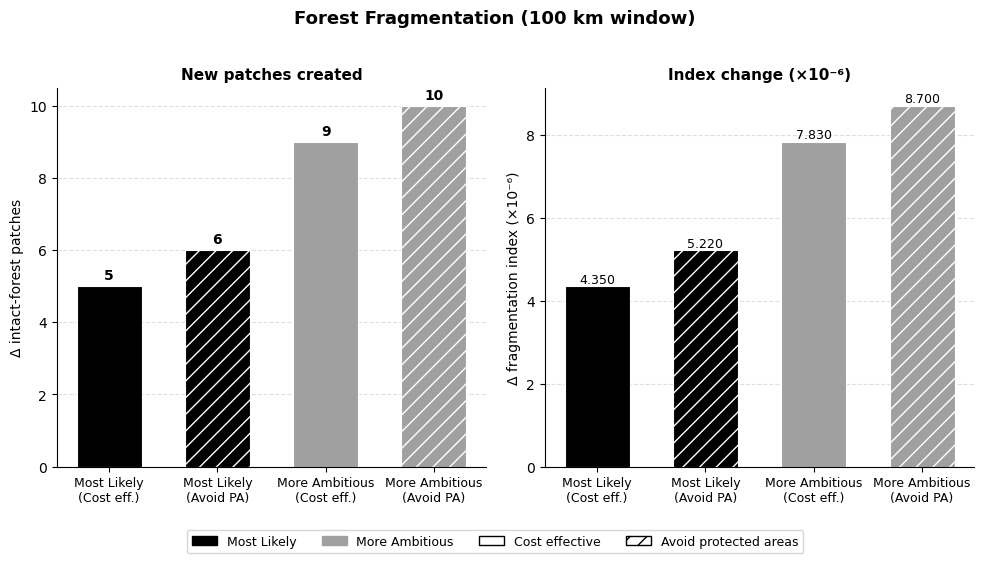

In [46]:
# Fragmentation index change and affected windows — combined 2-panel figure
STAGE_ORDER = ["Late Stage Only", "Late + Early Stage"]
df_sorted = df.set_index("mining_stage").loc[STAGE_ORDER].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Forest Fragmentation (100 km window)",
             fontsize=13, fontweight="bold", y=1.02)

scen_labels = [
    f"{'Most Likely' if row['mining_stage']=='Late Stage Only' else 'More Ambitious'}\n"
    f"({'Cost eff.' if row['mask_type']=='No Mask' else 'Avoid PA'})"
    for _, row in df_sorted.iterrows()
]
scen_x = np.arange(len(df_sorted))
bar_colors  = ["#000000", "#000000", "#a0a0a0", "#a0a0a0"]
bar_hatches = ["", "//", "", "//"]

# Panel 1: Δ patches
ax = axes[0]
vals = df_sorted["delta_patches_100km"].values
bars = ax.bar(scen_x, vals, 0.6, color=bar_colors, edgecolor="white", linewidth=0.8)
for bar, hatch in zip(bars, bar_hatches):
    bar.set_hatch(hatch)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.1, str(int(v)),
            ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_xticks(scen_x); ax.set_xticklabels(scen_labels, fontsize=9)
ax.set_ylabel("Δ intact-forest patches")
ax.set_title("New patches created", fontsize=11, fontweight="bold")
ax.set_ylim(bottom=0); ax.yaxis.grid(True, linestyle="--", alpha=0.4); ax.set_axisbelow(True)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# Panel 2: Δ index (×10⁻⁶ for readability)
ax = axes[1]
vals = df_sorted["delta_index_100km"].values * 1e6
bars = ax.bar(scen_x, vals, 0.6, color=bar_colors, edgecolor="white", linewidth=0.8)
for bar, hatch in zip(bars, bar_hatches):
    bar.set_hatch(hatch)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.003, f"{v:.3f}",
            ha="center", va="bottom", fontsize=9)
ax.set_xticks(scen_x); ax.set_xticklabels(scen_labels, fontsize=9)
ax.set_ylabel("Δ fragmentation index (×10⁻⁶)")
ax.set_title("Index change (×10⁻⁶)", fontsize=11, fontweight="bold")
ax.set_ylim(bottom=0); ax.yaxis.grid(True, linestyle="--", alpha=0.4); ax.set_axisbelow(True)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# Shared legend (mining stage × mask)
legend_handles = [
    mpatches.Patch(color="#000000",           label="Most Likely"),
    mpatches.Patch(color="#a0a0a0",           label="More Ambitious"),
    mpatches.Patch(color="white", hatch="",   ec="black", label="Cost effective"),
    mpatches.Patch(color="white", hatch="//", ec="black", label="Avoid protected areas"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.08), frameon=True)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_fragmentation_detail.png", dpi=150, bbox_inches="tight")
plt.show()

Both fragmentation metrics confirm the same scenario ordering — More Ambitious > Most Likely, and avoid-protected-areas > cost-effective — but the absolute magnitudes are extremely small. The fragmentation index increases by only **0.44–0.87 × 10⁻⁶** across all scenarios, several orders of magnitude below the baseline index of ~0.089. This near-negligible landscape-level fragmentation impact is expected: road corridors occupy a tiny fraction of the 100 km windows, so their effect on patch statistics is diluted by the vast undisturbed forest area surrounding them. The patch count metric (left panel) is therefore a more sensitive and interpretable signal of local fragmentation than the index (right panel) at this spatial scale.

## Spatial fragmentation map

Which landscape windows gained new forest patches, and where are the roads that caused it?

Each cell = one 100 km × 100 km window. Colored cells are the windows where patch count increased after road construction. The right panel adds the action roads to show the direct cause.

C:\Users\Move\AppData\Local\Temp\ipykernel_21880\2485266479.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


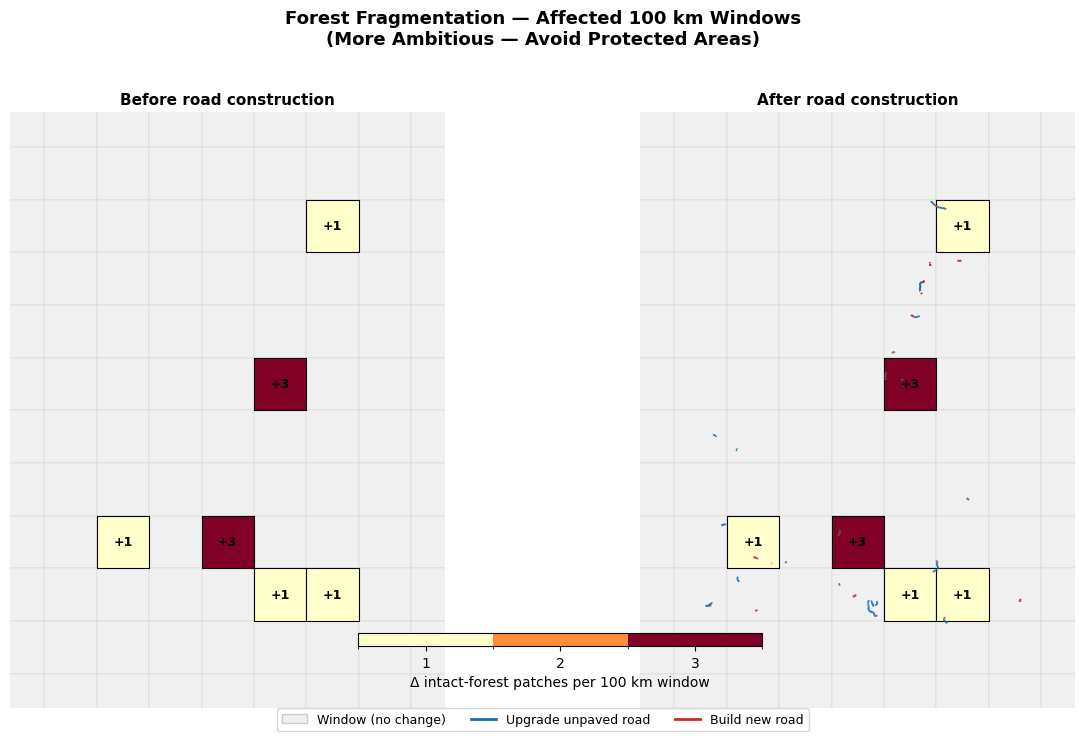

Affected windows: 6  |  Total Δ patches: 10


In [47]:
import rasterio
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.colors import BoundaryNorm
from shapely.geometry import box

SCENARIO_SPATIAL = "late_and_early_stage__kribi__base__protected_areas__ds1"
WINDOW_KM        = 100
NODATA_INT       = -1

# ── Load before / after / delta patch grid TIFs ───────────────────────────────
def load_patch_grid(fp):
    with rasterio.open(fp) as src:
        arr       = src.read(1).astype(float)
        transform = src.transform
        crs       = src.crs
        nodata    = src.nodata if src.nodata is not None else NODATA_INT
    arr[arr == nodata] = np.nan
    return arr, transform, crs

delta_arr,  grid_tf, grid_crs = load_patch_grid(
    RESULTS_DIR / f"fragmentation_patches_delta_{WINDOW_KM}km_{SCENARIO_SPATIAL}.tif")

# ── Build window polygons ─────────────────────────────────────────────────────
rows_idx, cols_idx = np.where(~np.isnan(delta_arr))
records = []
for r, c in zip(rows_idx, cols_idx):
    left   = grid_tf.c + c * grid_tf.a
    top    = grid_tf.f + r * grid_tf.e
    right  = left + grid_tf.a
    bottom = top  + grid_tf.e          # e is negative
    records.append({
        "delta":    delta_arr[r, c],
        "geometry": box(left, min(top, bottom), right, max(top, bottom))
    })

gdf_windows  = gpd.GeoDataFrame(records, crs=grid_crs)
gdf_affected = gdf_windows[gdf_windows["delta"] > 0].copy()

# ── Load action roads (upgrade + new build) ───────────────────────────────────
action_roads  = gpd.read_file(RESULTS_DIR / f"action_roads_{SCENARIO_SPATIAL}.gpkg")
upgrade_roads = action_roads[action_roads["action_needed"] == "upgrade"]
new_roads     = action_roads[action_roads["action_needed"] == "build"]

# ── Color scale: discrete by delta value ─────────────────────────────────────
max_delta  = int(gdf_affected["delta"].max())
cmap       = plt.cm.YlOrRd
boundaries = np.arange(0.5, max_delta + 1.5)
norm       = BoundaryNorm(boundaries, ncolors=cmap.N)

# ── Compute zoom extent from affected windows (+ padding) ────────────────────
bounds     = gdf_affected.total_bounds          # [minx, miny, maxx, maxy]
pad        = 1.5                                # degrees
xlim       = (bounds[0] - pad, bounds[2] + pad)
ylim       = (bounds[1] - pad, bounds[3] + pad)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True, sharey=True)
fig.suptitle(
    "Forest Fragmentation — Affected 100 km Windows\n(More Ambitious — Avoid Protected Areas)",
    fontsize=13, fontweight="bold", y=1.02
)

for ax, title, show_roads in zip(
        axes,
        ["Before road construction", "After road construction"],
        [False, True]):

    # Background: all processed windows in light gray
    gdf_windows.plot(ax=ax, color="#f0f0f0", edgecolor="#cccccc", linewidth=0.3)

    # Affected windows colored by Δ patches
    gdf_affected.plot(ax=ax, column="delta", cmap=cmap, norm=norm,
                      edgecolor="black", linewidth=0.8)

    # Annotate Δ value on each affected window
    for _, row in gdf_affected.iterrows():
        cx = row.geometry.centroid.x
        cy = row.geometry.centroid.y
        ax.annotate(f"+{int(row['delta'])}", xy=(cx, cy),
                    ha="center", va="center", fontsize=9,
                    fontweight="bold", color="black")

    # Action roads (right panel only)
    if show_roads:
        upgrade_roads.plot(ax=ax, color="#1a6fb5", linewidth=1.2, alpha=0.9, zorder=3)
        new_roads.plot(    ax=ax, color="#d62728", linewidth=1.5, alpha=0.9, zorder=3)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_axis_off()

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(),
                    orientation="horizontal", fraction=0.025, pad=0.04, aspect=30)
cbar.set_label("Δ intact-forest patches per 100 km window", fontsize=10)
cbar.set_ticks(np.arange(1, max_delta + 1))

# Legend
legend_handles = [
    mpatches.Patch(facecolor="#f0f0f0", edgecolor="#cccccc", label="Window (no change)"),
    mlines.Line2D([], [], color="#1a6fb5", linewidth=2, label="Upgrade unpaved road"),
    mlines.Line2D([], [], color="#d62728", linewidth=2, label="Build new road"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.02), frameon=True)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig_fragmentation_spatial.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Affected windows: {len(gdf_affected)}  |  Total Δ patches: {int(gdf_affected['delta'].sum())}")

Window: row=16, col=12  |  Δ patches = 3  |  bounds = (12.934750000000001, 6.3825, 13.38775, 6.835500000000001)
Patches before: 74  |  after: 76  |  Δ = 2
New (split-off) patches: 2


C:\Users\Move\AppData\Local\Temp\ipykernel_21880\3210049722.py:144: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=[1.0, 1.0, 1.0], edgecolor="gray", label="Non-forest"),


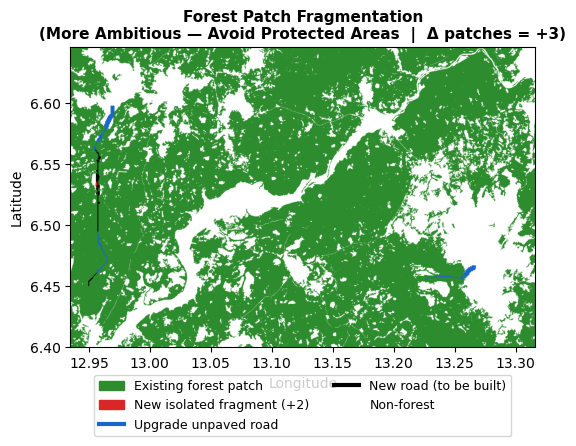

In [48]:
import rasterio
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import math
from collections import defaultdict
from scipy.ndimage import label as ndimage_label, binary_dilation
from rasterio.windows import from_bounds as window_from_bounds
from rasterio.warp import reproject as warp_reproject, Resampling as WarpResampling
from rasterio.features import rasterize

TREECOVER_FP     = Path("../data/output/processed-hansen-treecover/cameroon_treecover2024_30m.tif")
ROADS_FP         = Path("../data/output/processed_roads_official/cleaned_merged_osm_heigit_liu-ver3-midterm.gpkg")
CLASSIFIED_FP    = RESULTS_DIR / f"classified_{SCENARIO_SPATIAL}.tif"
FOREST_THRESHOLD = 10
MIN_FOREST_PATCH_KM2 = 0.01
STRUCT_8   = np.ones((3, 3), dtype=int)
ROAD_WIDTH = 5   # dilation radius in pixels (~150 m at 30 m resolution)

# ── Step 1: find the 50 km window with maximum Δ patches ─────────────────────
delta_50_arr, grid_tf_50, _ = load_patch_grid(
    RESULTS_DIR / f"fragmentation_patches_delta_50km_{SCENARIO_SPATIAL}.tif")

max_idx = np.unravel_index(np.nanargmax(delta_50_arr), delta_50_arr.shape)
grid_r, grid_c = max_idx
delta_val = int(delta_50_arr[grid_r, grid_c])

win_left   = grid_tf_50.c + grid_c * grid_tf_50.a
win_top    = grid_tf_50.f + grid_r * grid_tf_50.e
win_right  = win_left + grid_tf_50.a
win_bottom = win_top  + grid_tf_50.e
bounds = (min(win_left, win_right), min(win_top, win_bottom),
          max(win_left, win_right), max(win_top, win_bottom))
print(f"Window: row={grid_r}, col={grid_c}  |  Δ patches = {delta_val}  |  bounds = {bounds}")

# ── Step 2: load treecover ────────────────────────────────────────────────────
with rasterio.open(TREECOVER_FP) as tc_src:
    tc_win = window_from_bounds(*bounds, tc_src.transform).round_lengths().round_offsets()
    tc_arr = tc_src.read(1, window=tc_win)
    tc_tf  = tc_src.window_transform(tc_win)
    tc_crs = tc_src.crs

h, w = tc_arr.shape
lat_c        = tc_tf.f + (h / 2) * tc_tf.e
px_size_m    = abs(tc_tf.a) * 111_320 * math.cos(math.radians(lat_c))
px_area_km2  = (px_size_m ** 2) / 1_000_000
min_patch_px = max(1, round(MIN_FOREST_PATCH_KM2 / px_area_km2))
forest = (tc_arr >= FOREST_THRESHOLD).astype(np.uint8)

# ── Step 3: rasterize existing roads ─────────────────────────────────────────
roads_gdf = gpd.read_file(ROADS_FP, bbox=bounds)
if not roads_gdf.empty and roads_gdf.crs != tc_crs:
    roads_gdf = roads_gdf.to_crs(tc_crs)
road_raster = np.zeros((h, w), dtype=np.uint8)
if not roads_gdf.empty:
    road_raster = rasterize(
        [(geom, 1) for geom in roads_gdf.geometry if geom is not None],
        out_shape=(h, w), transform=tc_tf, fill=0, dtype=np.uint8)

# ── Step 4: reproject classified raster ──────────────────────────────────────
with rasterio.open(CLASSIFIED_FP) as cls_src:
    cls_full = cls_src.read(1)
    cls_tf   = cls_src.transform
    cls_crs  = cls_src.crs
cls_repr = np.zeros((h, w), dtype=np.uint8)
warp_reproject(source=cls_full, destination=cls_repr,
               src_transform=cls_tf, src_crs=cls_crs,
               dst_transform=tc_tf,  dst_crs=tc_crs,
               resampling=WarpResampling.nearest)

# ── Step 5: label before and after ───────────────────────────────────────────
def label_patches(forest_mask, min_px):
    labeled, _ = ndimage_label(forest_mask, structure=STRUCT_8)
    sizes = np.bincount(labeled.ravel()); sizes[0] = 0
    labeled[np.isin(labeled, np.where(sizes < min_px)[0])] = 0
    return labeled

forest_before = forest.copy(); forest_before[road_raster > 0] = 0
forest_after  = forest_before.copy(); forest_after[(cls_repr == 2) | (cls_repr == 3)] = 0

labeled_before = label_patches(forest_before, min_patch_px)
labeled_after  = label_patches(forest_after,  min_patch_px)
n_before = len(np.unique(labeled_before)) - 1
n_after  = len(np.unique(labeled_after))  - 1
print(f"Patches before: {n_before}  |  after: {n_after}  |  Δ = {n_after - n_before}")

# ── Step 6: identify new (split-off) patches ─────────────────────────────────
after_sizes = np.bincount(labeled_after.ravel()); after_sizes[0] = 0
before_to_after = defaultdict(set)
valid = labeled_after > 0
for b_id, a_id in zip(labeled_before[valid].ravel(), labeled_after[valid].ravel()):
    before_to_after[b_id].add(a_id)

new_patch_ids = set()
for b_id, a_set in before_to_after.items():
    if len(a_set) > 1:
        largest = max(a_set, key=lambda a: after_sizes[a] if a < len(after_sizes) else 0)
        new_patch_ids.update(a_set - {largest})

print(f"New (split-off) patches: {len(new_patch_ids)}")

# ── Step 7: build RGB image ───────────────────────────────────────────────────
# Paint order: roads first, then patches on top — so small fragments are never buried
disk = np.ones((2 * ROAD_WIDTH + 1, 2 * ROAD_WIDTH + 1), dtype=bool)
upgrade_thick   = binary_dilation(cls_repr == 2, structure=disk)
new_build_thick = binary_dilation(cls_repr == 3, structure=disk)

rgb = np.ones((h, w, 3), dtype=np.float32)                              # white = non-forest
rgb[upgrade_thick]                               = [0.10, 0.40, 0.80]  # blue  = upgrade road
rgb[new_build_thick]                             = [0.0,  0.0,  0.0]   # black = new build road
rgb[labeled_after > 0]                           = [0.18, 0.55, 0.18]  # green = existing patch
rgb[np.isin(labeled_after, list(new_patch_ids))] = [0.85, 0.15, 0.15]  # red   = new fragment (painted last)

# ── Step 8: zoom to action road bounding box ─────────────────────────────────
action_px = np.where((cls_repr == 2) | (cls_repr == 3))
PAD = 200
r0 = max(0,   action_px[0].min() - PAD)
r1 = min(h-1, action_px[0].max() + PAD)
c0 = max(0,   action_px[1].min() - PAD)
c1 = min(w-1, action_px[1].max() + PAD)

rgb_crop    = rgb[r0:r1, c0:c1]
extent_crop = [tc_tf.c + c0 * tc_tf.a, tc_tf.c + c1 * tc_tf.a,
               tc_tf.f + r1 * tc_tf.e, tc_tf.f + r0 * tc_tf.e]

# ── Step 9: plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 10))
fig.subplots_adjust(bottom=0.18)
ax.imshow(rgb_crop, extent=extent_crop, origin="upper", aspect="equal")
ax.set_title(
    f"Forest Patch Fragmentation\n"
    f"(More Ambitious — Avoid Protected Areas  |  Δ patches = +{delta_val})",
    fontsize=11, fontweight="bold"
)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

legend_handles = [
    mpatches.Patch(color=[0.18, 0.55, 0.18], label="Existing forest patch"),
    mpatches.Patch(color=[0.85, 0.15, 0.15], label=f"New isolated fragment (+{len(new_patch_ids)})"),
    mlines.Line2D([], [], color=[0.10, 0.40, 0.80], linewidth=3, label="Upgrade unpaved road"),
    mlines.Line2D([], [], color=[0.0,  0.0,  0.0],  linewidth=3, label="New road (to be built)"),
    mpatches.Patch(color=[1.0, 1.0, 1.0], edgecolor="gray", label="Non-forest"),
]
ax.legend(handles=legend_handles, loc="upper center",
          bbox_to_anchor=(0.5, -0.07), ncol=2, fontsize=9, frameon=True)

plt.savefig(RESULTS_DIR / "fig_fragmentation_patches.png", dpi=150, bbox_inches="tight")
plt.show()